<a href="https://colab.research.google.com/github/Ronglawan/PROJECT_PHY_483/blob/main/MINI_PROJECT_PHY_483.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import libraries

In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

from tensorflow import keras
from tensorflow.keras import layers

#Load dataset

In [175]:
url = "https://raw.githubusercontent.com/Ronglawan/PROJECT_PHY_483/refs/heads/main/ev_battery_qc_data_2026_kaggle.csv"

df = pd.read_csv(url)
df.head()
display(df.head())

,Cell_ID,Batch_ID,Production_Line,Shift,Supplier,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct,Defect_Type,Inspector_Comment,QC_Grade
0,CELL-004920,BTH-0001,Line_3,Evening,ChemCorp,20.76,0.108,14.81,14.01,4980.0,97.79,Poor Retention,NaN,Scrap
1,CELL-014782,BTH-0001,Line_1,Night,ChemCorp,22.38,0.126,14.96,14.70,4989.0,97.35,NaN,NaN,Grade A
2,CELL-019348,BTH-0001,Line_2,Night,LithioMat,20.18,0.135,14.97,13.80,5032.0,96.77,NaN,Routine visual inspection passed.,Grade A
3,CELL-008537,BTH-0001,Line_2,Morning,VoltIndustries,24.30,0.162,14.84,14.65,5042.0,95.88,NaN,NaN,Grade A
4,CELL-010539,BTH-0001,Line_1,Evening,VoltIndustries,22.22,0.130,14.89,15.04,4943.0,97.74,High Internal Resistance,NaN,Grade A


In [176]:
display(pd.DataFrame(df.columns, columns=['Column Name']))

,Column Name
0,Cell_ID
1,Batch_ID
2,Production_Line
3,Shift
4,Supplier
5,Ambient_Temp_C
6,Anode_Overhang_mm
7,Electrolyte_Volume_ml
8,Internal_Resistance_mOhm
9,Capacity_mAh


##Data preprocessing

In [177]:
# ลบคอลัมน์ที่ไม่จำเป็น + กัน data leakage
df = df.drop(['Cell_ID','Batch_ID','Inspector_Comment','Defect_Type'], axis=1)

# จัดการ missing
df = df.dropna()

# Encode
le = LabelEncoder()
df['Production_Line'] = le.fit_transform(df['Production_Line'])
df['Shift'] = le.fit_transform(df['Shift'])
df['Supplier'] = le.fit_transform(df['Supplier'])
df['QC_Grade'] = le.fit_transform(df['QC_Grade'])

##Split data

In [178]:
X = df.drop('QC_Grade', axis=1)
y = df['QC_Grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##Normalize data

In [179]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Method
##Model 1: Deep Learning

In [180]:
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001
    )
]

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


388/388 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7970 - loss: 0.4633 - val_accuracy: 0.9346 - val_loss: 0.1911 - learning_rate: 0.0010
Epoch 2/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8776 - loss: 0.2874 - val_accuracy: 0.9436 - val_loss: 0.1494 - learning_rate: 0.0010
Epoch 3/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8928 - loss: 0.2490 - val_accuracy: 0.9568 - val_loss: 0.1315 - learning_rate: 0.0010
Epoch 4/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9029 - loss: 0.2337 - val_accuracy: 0.9552 - val_loss: 0.1336 - learning_rate: 0.0010
Epoch 5/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9150 - loss: 0.1995 - val_accuracy: 0.9581 - val_loss: 0.1124 - learning_rate: 0.0010
Epoch 6/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9187 - loss: 0.1984 - val_accuracy: 0.9620 - val_loss: 0.1185 - learning_rate: 0.0010
Epoch 7/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9273 - loss: 0.1715 - val_accurac

## Deep Learning Training History (Accuracy & Loss)

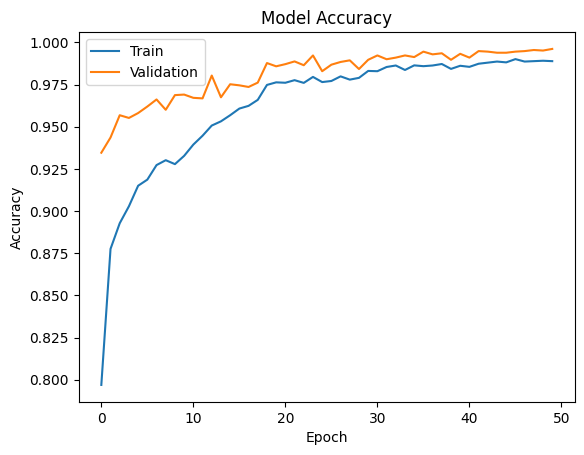

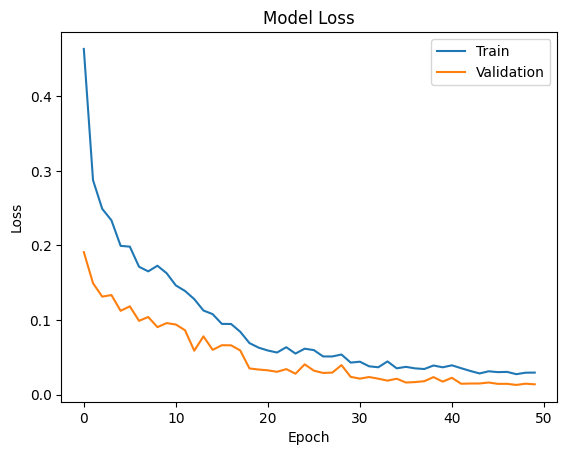

In [181]:
# Model Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

#Model Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

##Evaluate DL

In [182]:
# 1. ทำนายผล (Predict)
y_pred_dl = model.predict(X_test)
y_pred_dl = np.argmax(y_pred_dl, axis=1)

# 2. แสดงค่า Accuracy
print(f"Deep Learning Accuracy: {accuracy_score(y_test, y_pred_dl):.4f}")

# 3. แสดง Classification Report (รายละเอียดความแม่นยำในแต่ละเกรด)
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_dl))

122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Deep Learning Accuracy: 0.9936

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2603
           1       0.98      0.98      0.98       689
           2       0.99      0.99      0.99       588

    accuracy                           0.99      3880
   macro avg       0.99      0.99      0.99      3880
weighted avg       0.99      0.99      0.99      3880



##Confusion Matrix

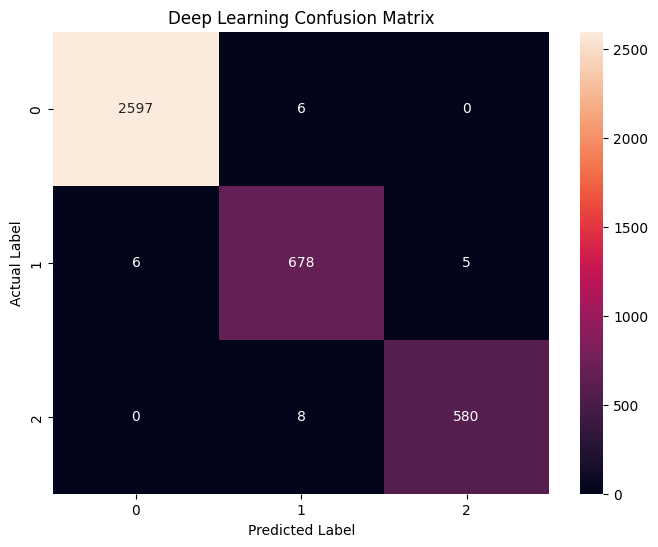

In [183]:
cm = confusion_matrix(y_test, y_pred_dl)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Deep Learning Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

##Model 2: Random Forest

##Train Model

In [184]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [185]:
from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2603
           1       1.00      1.00      1.00       689
           2       1.00      1.00      1.00       588

    accuracy                           1.00      3880
   macro avg       1.00      1.00      1.00      3880
weighted avg       1.00      1.00      1.00      3880



##Confusion Matrix

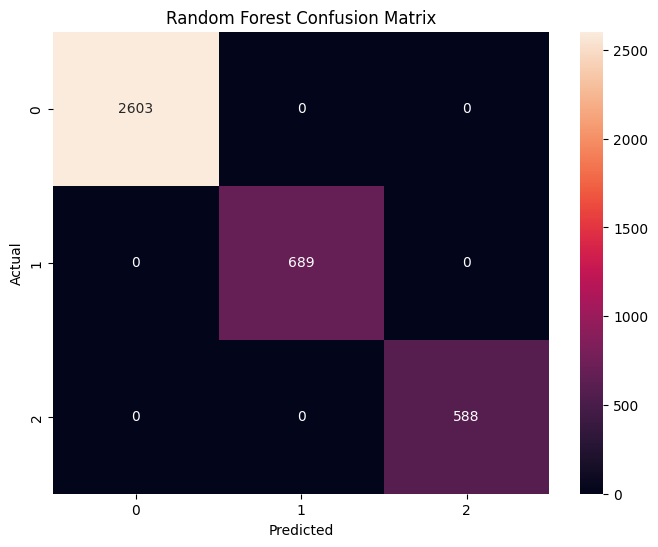

In [186]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Feature Importance

In [187]:
import pandas as pd

# ดึงค่าความสำคัญ
importance = rf.feature_importances_

# ชื่อ feature
features = X.columns

# สร้างตาราง
imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

# เรียงจากมากไปน้อย
imp_df = imp_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
imp_df.index += 1

display(imp_df)

,Feature,Importance
1,Anode_Overhang_mm,0.752483
2,Internal_Resistance_mOhm,0.159068
3,Capacity_mAh,0.045247
4,Retention_50Cycle_Pct,0.020755
5,Electrolyte_Volume_ml,0.012604
6,Ambient_Temp_C,0.005180
7,Supplier,0.003477
8,Production_Line,0.000602
9,Shift,0.000585


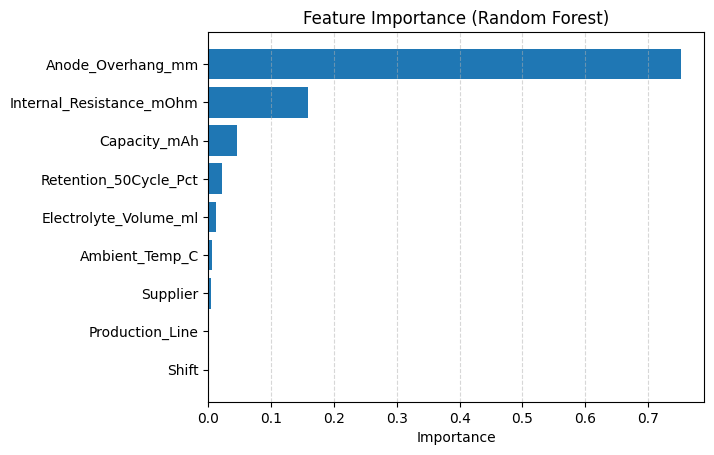

In [188]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(imp_df['Feature'], imp_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

## Model Prediction Preview

In [189]:
labels = ['Grade A','Grade B','Scrap']
pred_labels = [labels[i] for i in y_pred_rf]

for i in range(10):
    print("Actual:", y_test.iloc[i], "| Predicted:", pred_labels[i])

Actual: 0 | Predicted: Grade A
Actual: 2 | Predicted: Scrap
Actual: 1 | Predicted: Grade B
Actual: 0 | Predicted: Grade A
Actual: 0 | Predicted: Grade A
Actual: 2 | Predicted: Scrap
Actual: 2 | Predicted: Scrap
Actual: 1 | Predicted: Grade B
Actual: 0 | Predicted: Grade A
Actual: 2 | Predicted: Scrap


## Model Performance Comparison

In [190]:
# สร้างตารางสำหรับ Deep Learning
report_dl = classification_report(y_test, y_pred_dl, output_dict=True)
df_dl = pd.DataFrame(report_dl).transpose()

# สร้างตารางสำหรับ Random Forest
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
df_rf = pd.DataFrame(report_rf).transpose()

# สร้างตารางสรุปผลเปรียบเทียบ
results = {
    'Metric': ['Accuracy', 'F1-Score (Weighted)'],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        # ใช้ค่า weighted avg จาก classification report
        classification_report(y_test, y_pred_rf, output_dict=True)['weighted avg']['f1-score']
    ],
    'Deep Learning': [
        accuracy_score(y_test, y_pred_dl),
        # ใช้ค่า weighted avg จาก classification report
        classification_report(y_test, y_pred_dl, output_dict=True)['weighted avg']['f1-score']
    ]
}

df_summary = pd.DataFrame(results)

print("=== Deep Learning Classification Report ===")
display(df_dl)

print("\n=== Random Forest Classification Report ===")
display(df_rf)

print("=== สรุปผลเปรียบเทียบประสิทธิภาพโมเดล ===")
display(df_summary)

=== Deep Learning Classification Report ===


,precision,recall,f1-score,support
0,0.997695,0.997695,0.997695,2603.000000
1,0.979769,0.984035,0.981897,689.000000
2,0.991453,0.986395,0.988917,588.000000
accuracy,0.993557,0.993557,0.993557,0.993557
macro avg,0.989639,0.989375,0.989503,3880.000000
weighted avg,0.993566,0.993557,0.993559,3880.000000



=== Random Forest Classification Report ===


,precision,recall,f1-score,support
0,1.0,1.0,1.0,2603.0
1,1.0,1.0,1.0,689.0
2,1.0,1.0,1.0,588.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,3880.0
weighted avg,1.0,1.0,1.0,3880.0


=== สรุปผลเปรียบเทียบประสิทธิภาพโมเดล ===


,Metric,Random Forest,Deep Learning
0,Accuracy,1.0,0.993557
1,F1-Score (Weighted),1.0,0.993559
